In [4]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import os
import pandas as pd
import pickle
import json
import dit
import subprocess
from dit import Distribution
from dit.shannon import mutual_information as mi
from emergence.calc.dit import DitDistCalc
from emergence.micalc import MutualInfo
from emergence.utils.jvm import JVM
import ptitprince as pt

In [5]:
path = "gameDumps/scaleanalysis"
num_runs = 20

pairs_psi = []
triplets_psi = []
quadruplets_psi = []
quintuplets_psi = []

In [6]:
# Step 1: run all the experiments
for i in range(num_runs):
        command = "go run ."
        subprocess.run(command, shell=True)

In [8]:
# pairs
for file in os.listdir(path):
    joint_counts = {}
    total = 0
    with open(f"{path}/{file}", 'r') as f:
        data = json.load(f)
        all_agent_uuids = data["agentUUIDS"]
        all_bike_uuids = data["bikeUUIDS"]
        agent_uuid_to_idx = {uuid: idx for idx, uuid in enumerate(all_agent_uuids)}
        bike_uuid_to_idx = {uuid: idx for idx, uuid in enumerate(all_bike_uuids)}
        for iteration in data["iterations"]:
            agentBikes = iteration.get("agentBikes")
            agent_ids = list(agentBikes.keys())
            for i in range(len(agent_ids)):
              for j in range(i+1, len(agent_ids)):
                    a_id, b_id = agent_ids[i], agent_ids[j]
                    a = agent_uuid_to_idx[a_id]
                    b = agent_uuid_to_idx[b_id]
                    bike_a = bike_uuid_to_idx[agentBikes[a_id]]
                    bike_b = bike_uuid_to_idx[agentBikes[b_id]]
                    same_bike = int(bike_a == bike_b)
                    key = (a, b, same_bike)
                    joint_counts[key] = joint_counts.get(key, 0) + 1
                    total += 1

    outcomes = list(joint_counts.keys())
    probs = [joint_counts[o] / total for o in outcomes]

    dist = Distribution(outcomes, probs)
    calc = DitDistCalc(dist, mi)
    psi = calc.psi(q=2)
    pairs_psi.append(psi)


In [10]:
# triplets
for file in os.listdir(path):
    joint_counts = {}
    total = 0
    with open(f"{path}/{file}", 'r') as f:
        data = json.load(f)
        all_agent_uuids = data["agentUUIDS"]
        all_bike_uuids = data["bikeUUIDS"]
        agent_uuid_to_idx = {uuid: idx for idx, uuid in enumerate(all_agent_uuids)}
        bike_uuid_to_idx = {uuid: idx for idx, uuid in enumerate(all_bike_uuids)}

        for iteration in data["iterations"]:
            agentBikes = iteration.get("agentBikes")
            agent_ids = list(agentBikes.keys())
            for i in range(len(agent_ids)):
                for j in range(i+1, len(agent_ids)):
                    for k in range(j+1, len(agent_ids)):
                        a_id, b_id, c_id = agent_ids[i], agent_ids[j], agent_ids[k]
                        a = agent_uuid_to_idx[a_id]
                        b = agent_uuid_to_idx[b_id]
                        c = agent_uuid_to_idx[c_id]
                        bike_a = bike_uuid_to_idx[agentBikes[a_id]]
                        bike_b = bike_uuid_to_idx[agentBikes[b_id]]
                        bike_c = bike_uuid_to_idx[agentBikes[c_id]]
                        same_bike = int((bike_a == bike_b) and (bike_b == bike_c))
                        key = (a, b, c, same_bike)
                        joint_counts[key] = joint_counts.get(key, 0) + 1
                        total += 1

    outcomes = list(joint_counts.keys())
    probs = [joint_counts[o] / total for o in outcomes]

    dist = Distribution(outcomes, probs)
    calc = DitDistCalc(dist, mi)
    psi = calc.psi(q=3)
    triplets_psi.append(psi)

In [11]:
# quadruplets
for file in os.listdir(path):
    joint_counts = {}
    total = 0
    with open(f"{path}/{file}", 'r') as f:
        data = json.load(f)
        all_agent_uuids = data["agentUUIDS"]
        all_bike_uuids = data["bikeUUIDS"]
        agent_uuid_to_idx = {uuid: idx for idx, uuid in enumerate(all_agent_uuids)}
        bike_uuid_to_idx = {uuid: idx for idx, uuid in enumerate(all_bike_uuids)}

        for iteration in data["iterations"]:
            agentBikes = iteration.get("agentBikes")
            agent_ids = list(agentBikes.keys())
            for i in range(len(agent_ids)):
                for j in range(i+1, len(agent_ids)):
                    for k in range(j+1, len(agent_ids)):
                        for l in range(k+1, len(agent_ids)):
                            a_id, b_id, c_id, d_id = agent_ids[i], agent_ids[j], agent_ids[k], agent_ids[l]
                            a = agent_uuid_to_idx[a_id]
                            b = agent_uuid_to_idx[b_id]
                            c = agent_uuid_to_idx[c_id]
                            d = agent_uuid_to_idx[d_id]
                            bike_a = bike_uuid_to_idx[agentBikes[a_id]]
                            bike_b = bike_uuid_to_idx[agentBikes[b_id]]
                            bike_c = bike_uuid_to_idx[agentBikes[c_id]]
                            bike_d = bike_uuid_to_idx[agentBikes[d_id]]
                            same_bike = int((bike_a == bike_b) and (bike_b == bike_c) and (bike_c == bike_d))
                            key = (a, b, c, d, same_bike)
                            joint_counts[key] = joint_counts.get(key, 0) + 1
                            total += 1

    outcomes = list(joint_counts.keys())
    probs = [joint_counts[o] / total for o in outcomes]

    dist = Distribution(outcomes, probs)
    calc = DitDistCalc(dist, mi)
    psi = calc.psi(q=4)
    quadruplets_psi.append(psi)

In [12]:
# quintuplets
for file in os.listdir(path):
    joint_counts = {}
    total = 0
    with open(f"{path}/{file}", 'r') as f:
        data = json.load(f)
        all_agent_uuids = data["agentUUIDS"]
        all_bike_uuids = data["bikeUUIDS"]
        agent_uuid_to_idx = {uuid: idx for idx, uuid in enumerate(all_agent_uuids)}
        bike_uuid_to_idx = {uuid: idx for idx, uuid in enumerate(all_bike_uuids)}

        for iteration in data["iterations"]:
            agentBikes = iteration.get("agentBikes")
            agent_ids = list(agentBikes.keys())
            for i in range(len(agent_ids)):
                for j in range(i+1, len(agent_ids)):
                    for k in range(j+1, len(agent_ids)):
                        for l in range(k+1, len(agent_ids)):
                            for m in range(l+1, len(agent_ids)):
                                a_id, b_id, c_id, d_id, e_id = agent_ids[i], agent_ids[j], agent_ids[k], agent_ids[l], agent_ids[m]
                                a = agent_uuid_to_idx[a_id]
                                b = agent_uuid_to_idx[b_id]
                                c = agent_uuid_to_idx[c_id]
                                d = agent_uuid_to_idx[d_id]
                                e = agent_uuid_to_idx[e_id]
                                bike_a = bike_uuid_to_idx[agentBikes[a_id]]
                                bike_b = bike_uuid_to_idx[agentBikes[b_id]]
                                bike_c = bike_uuid_to_idx[agentBikes[c_id]]
                                bike_d = bike_uuid_to_idx[agentBikes[d_id]]
                                bike_e = bike_uuid_to_idx[agentBikes[e_id]]
                                same_bike = int((bike_a == bike_b) and (bike_b == bike_c) and (bike_c == bike_d) and (bike_d == bike_e))
                                key = (a, b, c, d, e, same_bike)
                                joint_counts[key] = joint_counts.get(key, 0) + 1
                                total += 1

    outcomes = list(joint_counts.keys())
    probs = [joint_counts[o] / total for o in outcomes]

    dist = Distribution(outcomes, probs)
    calc = DitDistCalc(dist, mi)
    psi = calc.psi(q=5)
    quintuplets_psi.append(psi)

<Axes: xlabel='Group size', ylabel='Psi'>

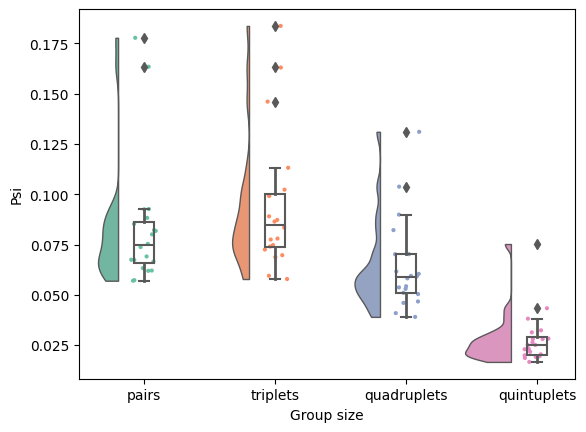

In [14]:
values = np.concatenate([pairs_psi, triplets_psi, quadruplets_psi, quintuplets_psi])
groups = (["pairs"] * num_runs +
          ["triplets"] * num_runs +
          ["quadruplets"] * num_runs +
          ["quintuplets"] * num_runs)

df = pd.DataFrame({
    "Psi": values,
    "Group size": groups
})

pt.RainCloud(x="Group size", y="Psi", data=df, orient="v")

# # Adjust y-axis
# ax.set_ylim(0, 0.55)

In [ ]:
# Step 4: Cleanup
for file in os.listdir(voluntary_path):
     os.remove(f"{voluntary_path}/{file}")

for file in os.listdir(random_path):
     os.remove(f"{random_path}/{file}")